# Predicting person income category based on age and hours of work

### *Importing Libraries*

In [1]:
import pandas as pd
import numpy as np


### *Load Dataset*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
dataset=pd.read_csv('/content/drive/My Drive/Colab Notebooks/Datasets/salary.csv')

### *Summarize Dataset*

In [4]:
dataset.head()

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,<=50K
1,82,9,0,18,<=50K
2,66,10,0,40,<=50K
3,54,4,0,40,<=50K
4,41,10,0,40,<=50K


In [5]:
dataset.shape

(32561, 5)

In [9]:
dataset.isnull().sum()

,0
age,0
education.num,0
capital.gain,0
hours.per.week,0
income,0


### Preprocessing

In [13]:
dataset['income']=dataset['income'].map({'<=50K':0,'>50K':1}).astype("int64")

In [14]:
dataset.dtypes

,0
age,int64
education.num,int64
capital.gain,int64
hours.per.week,int64
income,int64


In [15]:
dataset.head()

,age,education.num,capital.gain,hours.per.week,income
0,90,9,0,40,0
1,82,9,0,18,0
2,66,10,0,40,0
3,54,4,0,40,0
4,41,10,0,40,0


### *Segregate Dataset into X(Input/IndependentVariable) & Y(Output/DependentVariable)*

In [17]:

x=dataset.iloc[:,[0,3]].values
y=dataset.iloc[:,-1:].values

### *Splitting Dataset into Train & Test*

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

### *Feature Scaling*
### we scale our data to make all the features contribute equally to the result

In [27]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

### finding best k value


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

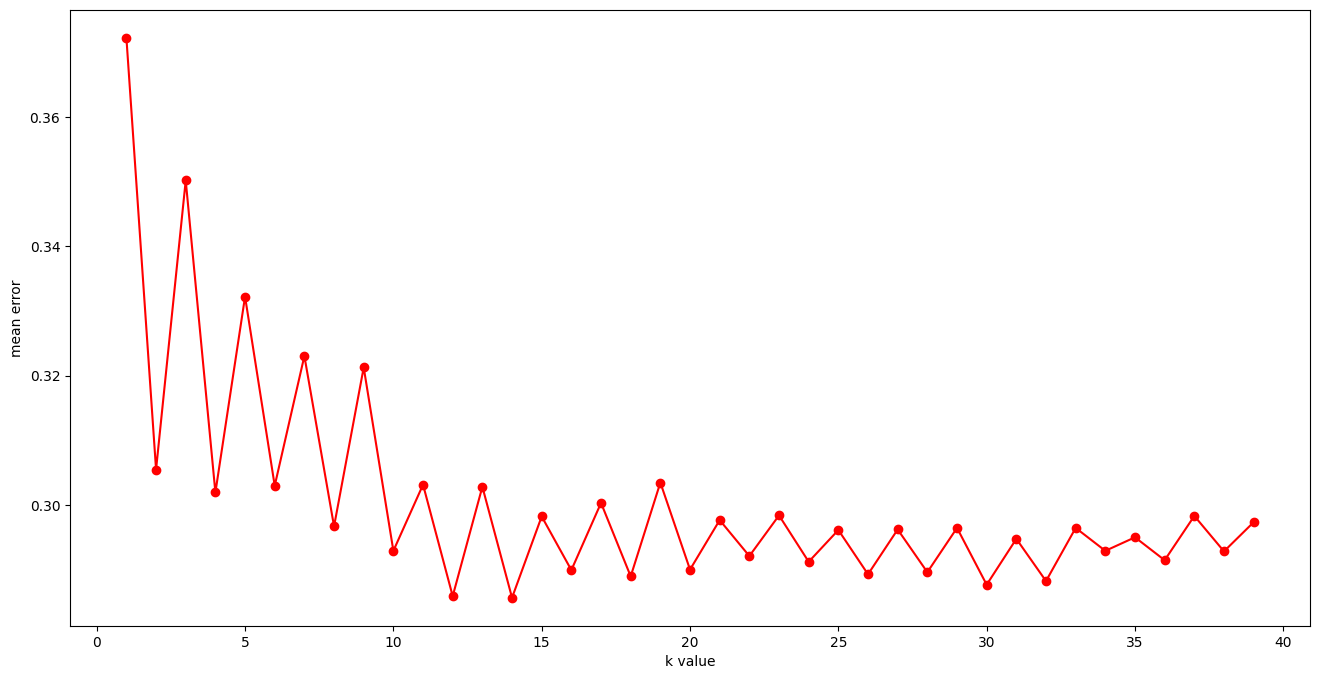

In [29]:
errors=[]
from matplotlib import pyplot as plt
for i in range(1,40):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(x_train,y_train)
  y_res=model.predict(x_test)

  errors.append(np.mean(y_test!=y_res))
plt.figure(figsize=(16,8))
plt.plot(range(1,40),errors,linestyle='-',marker='o',color='r')
plt.xlabel("k value")
plt.ylabel("mean error")
plt.show()



### *Training*

In [21]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=38,metric="minkowski",p=2)
model.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=13)

In [35]:
age=int(input("enter age"))
wh=int(input("enter hours"))
data=[[age,wh]]
res=model.predict(scaler.transform(data))
if(res==1):
  print("greater than 50k")
else:
  print("lesser than 50k")

enter age34
enter hours67
lesser than 50k


### *Prediction for all Test Data

In [22]:
y_pred=model.predict(x_test)

### *Evaluating Model*

In [23]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [24]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[4563  403]
 [1140  407]]
0.7630892062029787
